# NYC Taxi Price Prediction

## Initialization 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("taxi_trip_pricing.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [3]:
df.isna().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [4]:
df.shape

(1000, 11)

In [5]:
data = df.dropna()

## Exploratory Data Anaylsis

In [6]:
data.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000
mean,27.772941,2.533808,3.509893,1.219858,0.288221,61.825089,57.663525
std,21.153175,1.108915,0.871082,0.430351,0.114834,32.128436,43.958741
min,1.270000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,13.135000,2.000000,2.722500,0.840000,0.190000,36.530000,33.583875
50%,26.420000,3.000000,3.545000,1.200000,0.280000,61.210000,50.157850
75%,38.827500,4.000000,4.260000,1.580000,0.387500,88.435000,69.146575
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [7]:
data[['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']].value_counts()

Time_of_Day  Day_of_Week  Traffic_Conditions  Weather
Afternoon    Weekday      Medium              Clear      46
                          Low                 Clear      34
Morning      Weekday      Low                 Clear      31
                          Medium              Clear      30
Afternoon    Weekend      Medium              Clear      26
                                                         ..
Evening      Weekday      High                Snow        1
             Weekend      Low                 Snow        1
Night        Weekday      High                Rain        1
                          Low                 Snow        1
             Weekend      Medium              Snow        1
Name: count, Length: 64, dtype: int64

In [8]:
data['Time_of_Day'].value_counts()

Time_of_Day
Afternoon    220
Morning      157
Evening      124
Night         61
Name: count, dtype: int64

In [9]:
data['Day_of_Week'].value_counts()

Day_of_Week
Weekday    381
Weekend    181
Name: count, dtype: int64

In [10]:
data['Traffic_Conditions'].value_counts()

Traffic_Conditions
Medium    236
Low       218
High      108
Name: count, dtype: int64

In [11]:
data['Weather'].value_counts()

Weather
Clear    386
Rain     134
Snow      42
Name: count, dtype: int64

In [12]:
ordinal_encoding = ['Day_of_Week']
OHencoding = ['Time_of_Day', 'Traffic_Conditions', 'Weather']

In [13]:
cols = data.columns
cols

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

<Axes: xlabel='Trip_Price', ylabel='Count'>

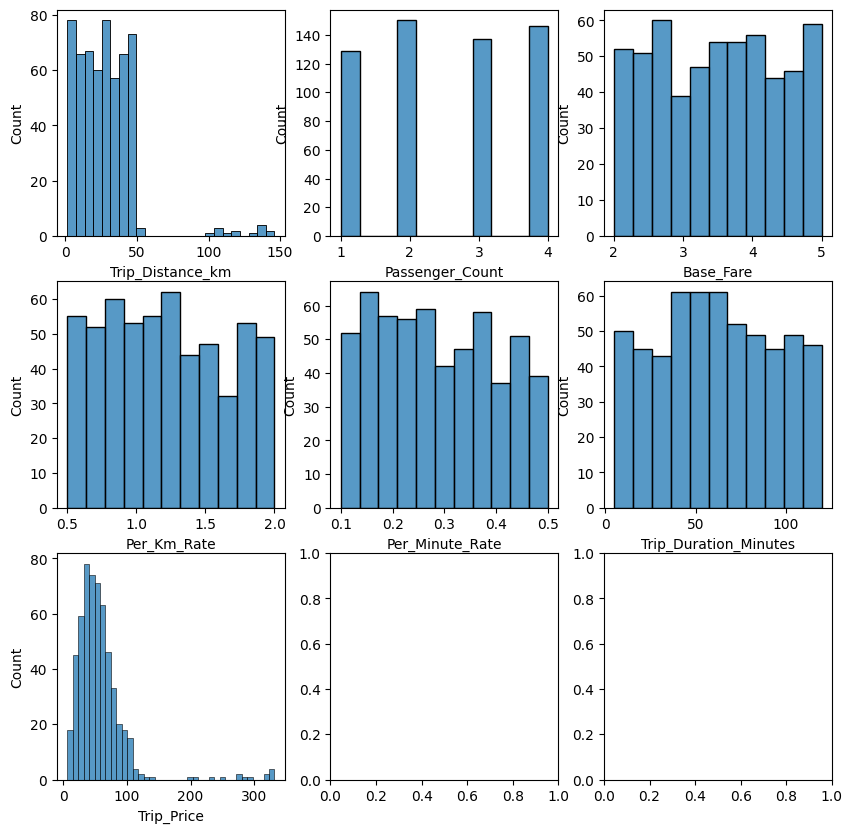

In [14]:
figure, axes = plt.subplots(3,3, figsize=(10,10))
numeric_cols = [cols[0], cols[3], cols[6],cols[7],cols[8],cols[9], cols[10]]
numeric_cols

for i in range(2):
    for j in range(3):
        sns.histplot(data=data, x=numeric_cols[(3*i)+j], ax=axes[i,j])

sns.histplot(data=data, x=numeric_cols[6], ax=axes[2,0])

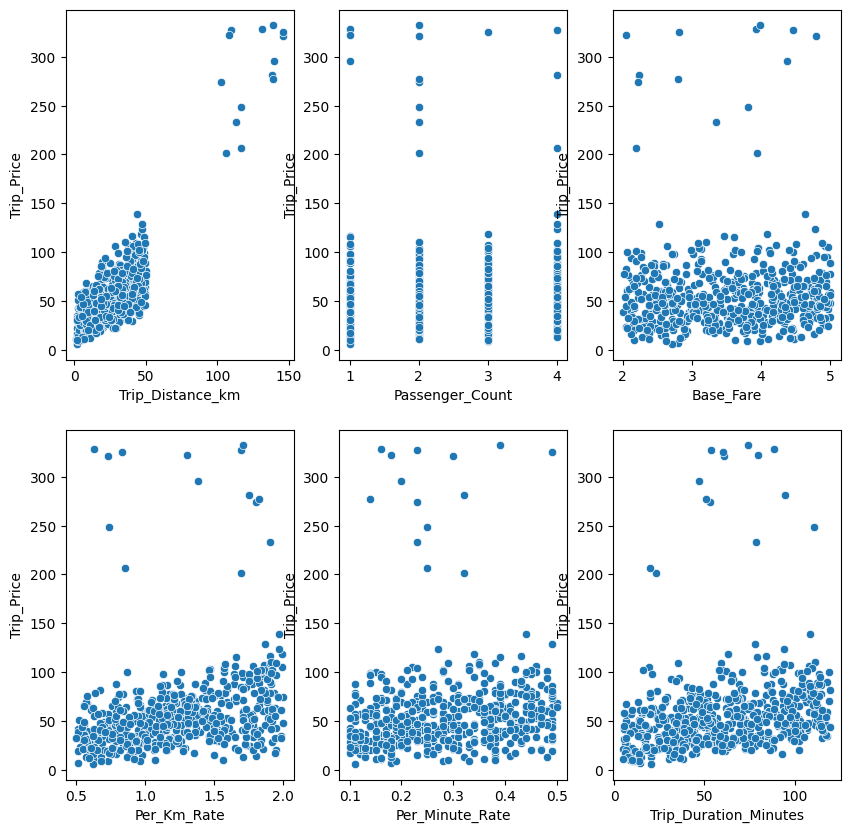

In [15]:
figure, axes = plt.subplots(2,3, figsize=(10,10))
numeric_cols = [cols[0], cols[3], cols[6],cols[7],cols[8],cols[9], cols[10]]
numeric_cols

for i in range(2):
    for j in range(3):
        sns.scatterplot(data=data, x=numeric_cols[(3*i)+j], y="Trip_Price", ax=axes[i,j])



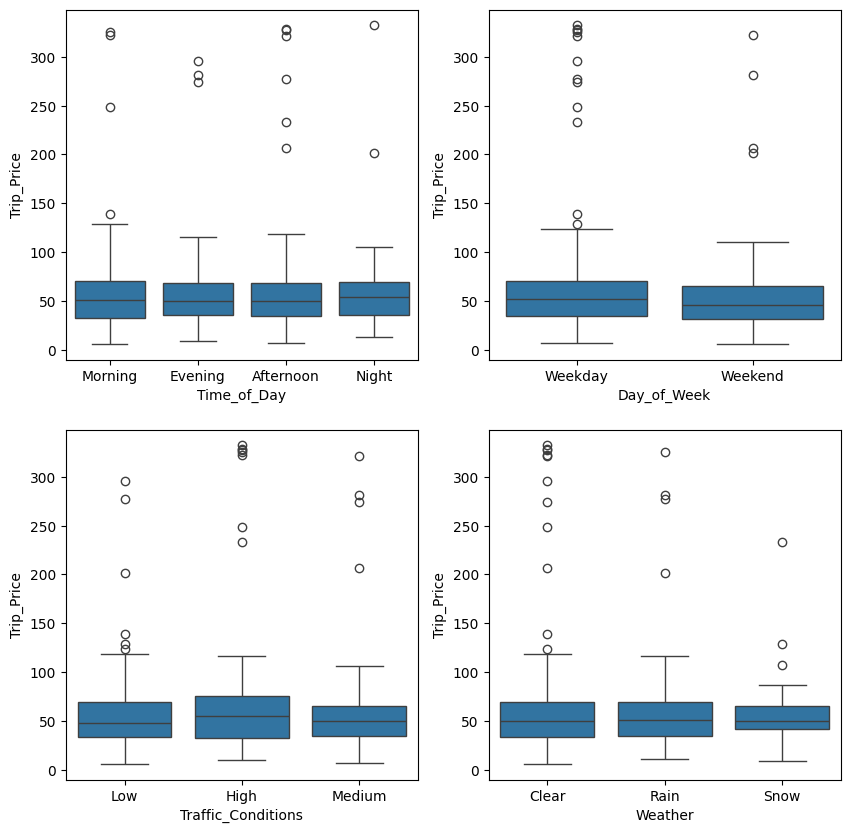

In [16]:
catgeroical = [cols[1],cols[2], cols[4], cols[5]]
figure, axes = plt.subplots(2,2, figsize=(10,10))

for i in range(2):
    for j in range(2):
        sns.boxplot(data=data, x=catgeroical[2*i+j], y='Trip_Price', ax =axes[i,j])

<Axes: >

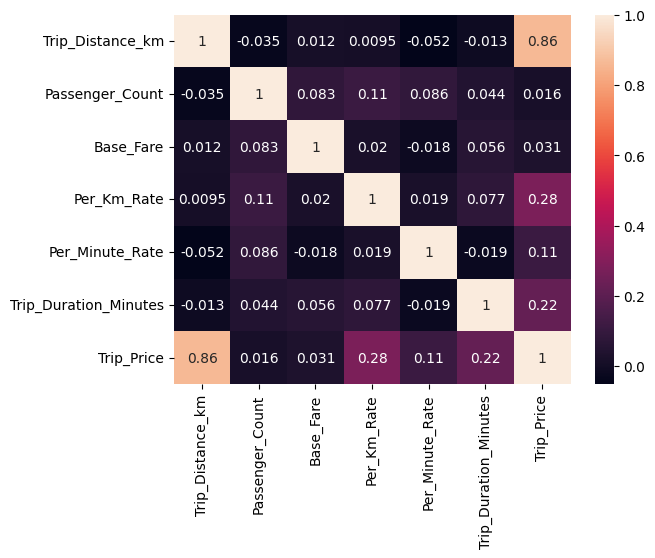

In [17]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr,  annot=True)

## Pipeline Creation and Fitting

In [18]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## Pipeline Evaluation 

In [19]:
numeric_imputer = SimpleImputer(strategy='mean')
catgeroical_imputer = SimpleImputer(strategy='most_frequent')

In [20]:
numeric_cols= numeric_cols[0:6]
numeric_cols

['Trip_Distance_km',
 'Passenger_Count',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes']

In [21]:
catgeroical

['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

In [22]:
OHE = OneHotEncoder()
OE = OrdinalEncoder()
Scaler = StandardScaler()

In [23]:
numeric_pipeline = Pipeline([
    ("imputer", numeric_imputer),
    ("Scaler", Scaler)
])

OneHot_pipeline = Pipeline([
    ('imputer', catgeroical_imputer),
    ('encoding', OHE),
])

Oridinal_pipeline = Pipeline([
    ('imputer', catgeroical_imputer),
    ('Ordinal', OE)
])

In [24]:
CT =  ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_cols),
        ("OneHot", OneHot_pipeline, OHencoding),
        ("oridinal", Oridinal_pipeline, ordinal_encoding)
    ]
)

In [25]:
pf = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

In [26]:
lasso = Pipeline([
    ("Preprocessing", CT),
    ("FreatureCreation", pf),
    ('model', Lasso())
])

In [27]:
TTR = TransformedTargetRegressor(
    regressor=lasso,
    transformer=Scaler
)

parameters = {'regressor__model__alpha': [0.0001,0.001,0.01,0.1,1]}

In [28]:
GS = GridSearchCV(
    TTR, 
    param_grid=parameters, 
    cv=5,
    scoring='r2'
)

In [29]:
X = df.drop(columns=['Trip_Price'])
y = df[['Trip_Price']]

In [30]:
y_imputer = SimpleImputer(strategy='mean')
y_imputed = y_imputer.fit_transform(y)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y_imputed,test_size=0.2, random_state=1128)

In [32]:
GS.fit(X_train,y_train)

d:\User\Vakeesan's Pc\Download\3.11 Python File\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.777e+00, tolerance: 6.400e-02
  model = cd_fast.enet_coordinate_descent(
d:\User\Vakeesan's Pc\Download\3.11 Python File\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.998e+00, tolerance: 6.400e-02
  model = cd_fast.enet_coordinate_descent(
d:\User\Vakeesan's Pc\Download\3.11 Python File\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...ndardScaler())
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__model__alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [ ]:
model = GS.best_estimator_

In [34]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)


0.8837417213574614

In [35]:
import joblib 

In [36]:
joblib.dump(model, 'taix_model_V1.0.0.pkl')

['taix_model_V1.0.0.pkl']

In [45]:
X_test.iloc[1]

Trip_Distance_km           46.35
Time_of_Day              Morning
Day_of_Week              Weekday
Passenger_Count              1.0
Traffic_Conditions        Medium
Weather                    Clear
Base_Fare                    3.1
Per_Km_Rate                 0.95
Per_Minute_Rate             0.24
Trip_Duration_Minutes      89.15
Name: 807, dtype: object

In [46]:
input_data = pd.DataFrame([{
    "Trip_Distance_km": 46.35,
    "Time_of_Day": "Morning",
    "Day_of_Week": "Weekday",
    "Passenger_Count": 1.0,
    "Traffic_Conditions": "Medium",
    "Weather": "Clear",
    "Base_Fare": 3.1,
    "Per_Km_Rate": 0.95,
    "Per_Minute_Rate": 0.24,
    "Trip_Duration_Minutes": 89.15
}])

model.predict(input_data)


array([[77.83543927]])